# 12.3 병든 잎사귀 식별 경진대회 베이스라인 모델
- [병든 잎사귀 식별 경진대회 링크](https://www.kaggle.com/c/plant-pathology-2020-fgvc7)
- [베이스라인 모델 코드 참고 링크](https://www.kaggle.com/akasharidas/plant-pathology-2020-in-pytorch)

## 12.3.1 시드값 고정 및 GPU 장비 설정
### 시드값 고정

In [1]:
import torch # 파이토치 
import random
import numpy as np
import os

# 시드값 고정
seed = 50
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

### GPU 장비 설정

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device

device(type='cuda')

## 12.3.2 데이터 준비

In [3]:
import pandas as pd

# 데이터 경로
data_path = '/kaggle/input/plant-pathology-2020-fgvc7/'

train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

### 훈련 데이터, 검증 데이터 분리

In [4]:
from sklearn.model_selection import train_test_split

# 훈련 데이터, 검증 데이터 분리
train, valid = train_test_split(train, 
                                test_size=0.1,
                                stratify=train[['healthy', 'multiple_diseases', 'rust', 'scab']],
                                random_state=50)

모듈1: 증강 기법 탐구

In [5]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- [1. 증강 시각화 도구 함수 정의] ---
def visualize_augmentations(img_id, transform, n_examples=4):
    """
    특정 이미지(img_id)에 transform 파이프라인을 n_examples번 적용하여 시각화합니다.
    """
    img_path = f'{data_path}images/{img_id}.jpg' # 경로 수정: data_path 끝에 '/'가 있으므로 images 앞에 '/' 제거
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, n_examples + 1, 1)
    plt.title("Original")
    plt.imshow(image)
    plt.axis('off')

    for i in range(n_examples):
        augmented = transform(image=image)['image']
        plt.subplot(1, n_examples + 1, i + 2)
        plt.title(f"Augmented {i+1}")
        plt.imshow(augmented)
        plt.axis('off')
    plt.show()

# =====================================================================
# [수정 위치 1] 시각화 셀 (transform_experimental이 있는 셀)
# =====================================================================
import albumentations as A

# --- [2. 탐구: 나만의 실험적 증강 파이프라인 작성] ---
transform_experimental = A.Compose([
    A.Resize(450, 650), 

    # =================================================================
    # [실험 3: 기하학적 왜곡 및 방향 변환]
    # 질병의 색상 정보는 온전히 보존하면서, 사진이 찍히는 각도나 
    # 잎사귀의 구부러짐(주름)을 흉내 내는 증강을 적용합니다.
    # =================================================================
    # A.Transpose(p=1.0),               # 대각선 대칭 변환 (눈으로 확인하기 위해 p=1.0)
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0) # 격자 형태의 왜곡
])


# visualize_augmentations(sample_img_id, transform_experimental, n_examples=4)


### 데이터셋 클래스 정의

In [6]:
import cv2
from torch.utils.data import Dataset # 데이터 생성을 위한 클래스
import numpy as np

class ImageDataset(Dataset):
    # 초기화 메서드(생성자)
    def __init__(self, df, img_dir='./', transform=None, is_test=False):
        super().__init__() # 상속받은 Dataset의 __init__() 메서드 호출
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
    
    # 데이터셋 크기 반환 메서드 
    def __len__(self):
        return len(self.df)
    
    # 인덱스(idx)에 해당하는 데이터 반환 메서드
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]             # 이미지 ID
        img_path = self.img_dir + img_id + '.jpg' # 이미지 파일 경로
        image = cv2.imread(img_path)              # 이미지 파일 읽기
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # 이미지 색상 보정
        # 이미지 변환 
        if self.transform is not None:
            image = self.transform(image=image)['image']
        # 테스트 데이터면 이미지 데이터만 반환, 그렇지 않으면 타깃값도 반환 
        if self.is_test:
            return image # 테스트용일 때
        else:
            # 타깃값 4개 중 가장 큰 값의 인덱스 
            label = np.argmax(self.df.iloc[idx, 1:5]) 
            return image, label # 훈련/검증용일 때

### 이미지 변환기 정의

In [7]:
# 이미지 변환을 위한 모듈
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [8]:
# =====================================================================
# [수정 위치 1] 훈련 데이터용 변환기 (transform_train) 셀
# 이전의 모든 증강 실험을 결합한 '최적의 레시피(Golden Recipe)'를 적용합니다.
# =====================================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform_train = A.Compose([
    A.Resize(450, 650), 
    A.VerticalFlip(p=0.2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.3),
    A.OneOf([A.Emboss(p=1), A.Sharpen(p=1), A.Blur(p=1)], p=0.3),
    A.PiecewiseAffine(p=0.3), 
    # A.Transpose(p=0.5),  <-- 완벽하게 지워졌거나 주석 처리됨!
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=50, max_width=50, min_holes=2, p=0.5),
    A.Normalize(),            
    ToTensorV2()              
])

In [9]:
# 검증 및 테스트 데이터용 변환기
transform_test = A.Compose([
    A.Resize(450, 650),  
    #A.Resize(224, 224),  # <-- (수정) 
    A.Normalize(),      # 정규화 변환
    ToTensorV2()        # 텐서로 변환
])

### 데이터셋 및 데이터 로더 생성

In [10]:
img_dir = '/kaggle/input/plant-pathology-2020-fgvc7/images/'

dataset_train = ImageDataset(train, img_dir=img_dir, transform=transform_train)
dataset_valid = ImageDataset(valid, img_dir=img_dir, transform=transform_test)

In [11]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    
g = torch.Generator()
g.manual_seed(0)

In [12]:
from torch.utils.data import DataLoader # 데이터 로더 클래스

batch_size = 4  
#batch_size = 32 # <-- (수정)

loader_train = DataLoader(dataset_train, batch_size=batch_size, 
                          shuffle=True, worker_init_fn=seed_worker,
                          generator=g, num_workers=2)
loader_valid = DataLoader(dataset_valid, batch_size=batch_size, 
                          shuffle=False, worker_init_fn=seed_worker,
                          generator=g, num_workers=2)

## 12.3.3 모델 생성

### EfficientNet 모델 생성

In [13]:
!pip install efficientnet-pytorch==0.7.1

  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16446 sha256=2ccfd3c661f0c4b3f2bcf22a678a49bda0b9f50ec5024020c4b6dc8fada0a008
  Stored in directory: /root/.cache/pip/wheels/0e/cc/b2/49e74588263573ff778da58cc99b9c6349b496636a7e165be6
Successfully built efficientnet-pytorch


In [14]:
from efficientnet_pytorch import EfficientNet # EfficientNet 모델

In [15]:
# model = EfficientNet.from_pretrained('efficientnet-b7', num_classes=4) <-- (기존 코드)

# (수정) b7을 b0로 변경합니다.
#model = EfficientNet.from_pretrained('efficientnet-b0', num_classes=4) 


# 🟢 [수정 후] 다시 b7로 복구
model = EfficientNet.from_pretrained('efficientnet-b7', num_classes=4)

model = model.to(device) # 장비 할당

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b7-dcc49843.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b7-dcc49843.pth


  0%|          | 0.00/254M [00:00<?, ?B/s]

Loaded pretrained weights for efficientnet-b7


## 12.3.4 모델 훈련 및 성능 검증

### 손실 함수와 옵티마이저 설정

In [16]:

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # <--- 바로 이 줄이 빠져서 났던 에러입니다!
from torch.optim.lr_scheduler import ReduceLROnPlateau


# =====================================================================
# 🛠️ [해결책] 파이토치 구버전에서도 작동하는 커스텀 라벨 스무딩 손실 함수
# =====================================================================
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, eps=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.eps = eps

    def forward(self, x, target):
        # x: 모델의 출력(예측 로짓), target: 실제 정답 인덱스
        log_preds = F.log_softmax(x, dim=-1)
        loss = -log_preds.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1) # 기존 교차 엔트로피 손실
        smooth_loss = -log_preds.mean(dim=-1) # 정답에 대한 확신을 깎아주는 스무딩 손실
        return ((1.0 - self.eps) * loss + self.eps * smooth_loss).mean()

# ---------------------------------------------------------------------
# 🎯 1. 손실 함수 (Loss Function) 선택
# ---------------------------------------------------------------------
# [수정됨] 에러가 났던 기본 함수 대신, 위에서 만든 커스텀 함수를 사용합니다.
criterion = LabelSmoothingCrossEntropy(eps=0.1)


# ---------------------------------------------------------------------
# 🚀 2. 옵티마이저 (Optimizer) 선택
# ---------------------------------------------------------------------
# [실험 A] 일반 Adam 테스트 (주석 해제 시 사용)
# optimizer = optim.Adam(model.parameters(), lr=0.00006)

# [실험 B / 권장] AdamW 유지 (가중치 감쇠 적용)
optimizer = optim.AdamW(model.parameters(), lr=0.00006, weight_decay=0.0001)

### 훈련 및 성능 검증

Epoch 1/15: 100%|██████████| 410/410 [05:59<00:00,  1.14it/s]


Train Loss: 0.8555 | Valid Loss: 0.5619 | Valid AUC: 0.9623 | LR: 0.000060
------------------------------------------------------------


Epoch 2/15: 100%|██████████| 410/410 [05:57<00:00,  1.15it/s]


Train Loss: 0.6157 | Valid Loss: 0.5494 | Valid AUC: 0.9766 | LR: 0.000060
------------------------------------------------------------


Epoch 3/15: 100%|██████████| 410/410 [05:54<00:00,  1.16it/s]


...

Train Loss: 0.3738 | Valid Loss: 0.5040 | Valid AUC: 0.9727 | LR: 0.000015
------------------------------------------------------------


Epoch 14/15: 100%|██████████| 410/410 [05:58<00:00,  1.14it/s]


Train Loss: 0.3764 | Valid Loss: 0.5012 | Valid AUC: 0.9764 | LR: 0.000008
------------------------------------------------------------


Epoch 15/15: 100%|██████████| 410/410 [05:58<00:00,  1.14it/s]


Train Loss: 0.3693 | Valid Loss: 0.4916 | Valid AUC: 0.9731 | LR: 0.000008
------------------------------------------------------------


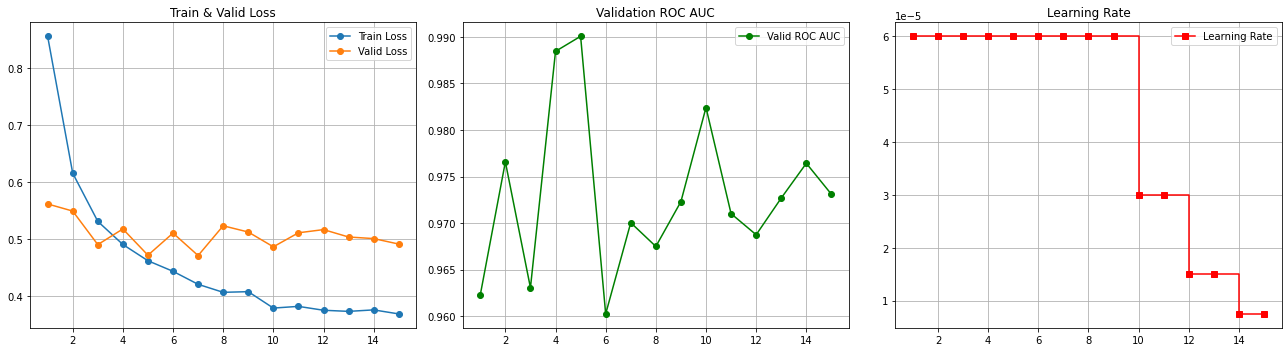

In [17]:
from sklearn.metrics import roc_auc_score # ROC AUC 점수 계산 함수
from tqdm import tqdm # 진행률 표시 막대 

# epochs = 5 <-- (기존 코드)
epochs = 15  # (수정)

# =================================================================
# 👇 교체할 코드 (스케줄러) 👇
from torch.optim.lr_scheduler import ReduceLROnPlateau 


scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
# =================================================================


# =====================================================================
# 6. 훈련 루프 및 📊 결과 추적
# =====================================================================
# 시각화 기록용 딕셔너리
history = {'train_loss': [], 'valid_loss': [], 'valid_auc': [], 'lr': []}

for epoch in range(epochs):
    # == [ 훈련 ] ==
    model.train()        
    epoch_train_loss = 0 
    
    for images, labels in tqdm(loader_train, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        epoch_train_loss += loss.item() 
        loss.backward() 
        optimizer.step() 
        
    avg_train_loss = epoch_train_loss / len(loader_train)
    
    # == [ 검증 ] ==
    model.eval()          
    epoch_valid_loss = 0  
    preds_list = []       
    true_onehot_list = [] 
    
    with torch.no_grad(): 
        for images, labels in loader_valid:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_valid_loss += loss.item()
            
            preds = torch.softmax(outputs.cpu(), dim=1).numpy() 
            true_onehot = torch.eye(4)[labels].cpu().numpy()  
            preds_list.extend(preds)
            true_onehot_list.extend(true_onehot)
            
    avg_valid_loss = epoch_valid_loss / len(loader_valid)
    valid_auc = roc_auc_score(true_onehot_list, preds_list)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f'Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f} | Valid AUC: {valid_auc:.4f} | LR: {current_lr:.6f}')  
    
    # 📊 수첩(history)에 기록 저장하기
    history['train_loss'].append(avg_train_loss)
    history['valid_loss'].append(avg_valid_loss)
    history['valid_auc'].append(valid_auc)
    history['lr'].append(current_lr)
    
    scheduler.step(avg_valid_loss) 
    print("-" * 60)


# ==========================================
# 🟢 [수정 후] 훈련 루프 셀 바로 아래에 이 그래프 코드를 추가하세요!
# 📈 훈련 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# 그래프 1: Train vs Valid Loss
plt.subplot(1, 3, 1)
plt.plot(range(1, epochs+1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), history['valid_loss'], label='Valid Loss', marker='o')
plt.title('Train & Valid Loss')
plt.legend()
plt.grid(True)

# 그래프 2: Valid ROC AUC
plt.subplot(1, 3, 2)
plt.plot(range(1, epochs+1), history['valid_auc'], label='Valid ROC AUC', color='green', marker='o')
plt.title('Validation ROC AUC')
plt.legend()
plt.grid(True)

# 그래프 3: Learning Rate
plt.subplot(1, 3, 3)
plt.plot(range(1, epochs+1), history['lr'], label='Learning Rate', color='red', marker='s', drawstyle='steps-post')
plt.title('Learning Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12.3.5 예측 및 결과 제출

In [18]:
ransform_tta = A.Compose([
    A.Resize(450, 650), # TTA 해상도 일치
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

num_tta = 5 
preds_tta = np.zeros((len(test), 4)) 

print(f"\n🚀 총 {num_tta}회의 최종 TTA 예측을 시작합니다...")

model.eval() 
with torch.no_grad():
    for i in range(num_tta):
        dataset_test_tta = ImageDataset(test, img_dir=img_dir, transform=transform_tta, is_test=True)
        loader_test_tta = DataLoader(dataset_test_tta, batch_size=batch_size, 
                                     shuffle=False, worker_init_fn=seed_worker, 
                                     generator=g, num_workers=2)
        
        print(f"--- TTA Step {i+1} / {num_tta} ---")
        
        for j, images in enumerate(tqdm(loader_test_tta)):
            images = images.to(device)
            outputs = model(images)
            
            # [버그 수정 완료] 차원 에러 방지
            preds_part = torch.softmax(outputs.cpu(), dim=1).numpy()
            
            start_idx = j * batch_size
            end_idx = start_idx + images.size(0)
            preds_tta[start_idx:end_idx] += preds_part

preds_tta /= num_tta

submission[['healthy', 'multiple_diseases', 'rust', 'scab']] = preds_tta
submission.to_csv('submission_final.csv', index=False)

print("✅ 최종 TTA 예측 완료! 'submission_final.csv' 파일이 성공적으로 생성되었습니다.")


🚀 총 5회의 최종 TTA 예측을 시작합니다...


NameError: name 'transform_tta' is not defined